In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

print("Loading cleaned datasets from Drive...")

X_train_scaled = pd.read_parquet('/content/drive/MyDrive/X_train_scaled.parquet')
X_test_scaled = pd.read_parquet('/content/drive/MyDrive/X_test_scaled.parquet')


y_train = pd.read_csv('/content/drive/MyDrive/y_train.csv')['is_attack']
y_test = pd.read_csv('/content/drive/MyDrive/y_test.csv')['is_attack']

print(f"Loaded X_train shape: {X_train_scaled.shape}")

Loading cleaned datasets from Drive...
Loaded X_train shape: (2262300, 44)


In [4]:
import joblib

print('Loading trained XGBoost model....')

xgb_model = joblib.load('/content/drive/MyDrive/xgboost_stage1.pkl')

print('XGBoost model loaded and ready')

Loading trained XGBoost model....
XGBoost model loaded and ready


In [5]:
from tensorflow.keras.models import load_model

print('Loading trained Autoencoder..')
autoencoder = load_model('/content/drive/MyDrive/autoencoder_stage2.h5', compile=False)

print('Autoencoder loaded and ready')

Loading trained Autoencoder..
Autoencoder loaded and ready


In [6]:
import json

print('Loading AE threshold')

with open('/content/drive/MyDrive/ae_threshold.json', 'r') as f:
  config = json.load(f)

best_threshold = config['best_threshold']

Loading AE threshold


In [7]:
print('Initializing the two stage SOC Pipeline...')

# step 1: The front door (XGBoost)
# pass all test traffic through the supervised model first

print('Stage 1: XGBoost scanning for known threats..')
xgb_predictions = xgb_model.predict(X_test_scaled)

Initializing the two stage SOC Pipeline...
Stage 1: XGBoost scanning for known threats..


In [8]:
# step 2: The Safety Net (Autoencoder)
# we only want the autoencoder to look at traffic that XGBoost thought was safe (0).
# if XGBoost already caught it, we don't need to double check it.

passed_by_xgboost_indices = np.where(xgb_predictions == 0)[0]
X_test_for_ae = X_test_scaled.iloc[passed_by_xgboost_indices]

print(f'Stage 2: Autoencoder scanning {len(X_test_for_ae)} benign packets for zero-days....')


Stage 2: Autoencoder scanning 454137 benign packets for zero-days....


In [9]:
# Get reconstructions errors for the traffic that slipped past XGBoost
reconstructions = autoencoder.predict(X_test_for_ae, verbose=0)
ae_errors = np.mean(np.abs(X_test_for_ae - reconstructions), axis=1)

# flag as a zero day (1) if the error is above our previously tuned threshold
ae_predictions = (ae_errors > best_threshold).astype(int)


In [10]:
# step 3: merging the results
hybrid_predictions = np.copy(xgb_predictions)

# update the final predictions with the zero days caught by the autoencoder
# if AE predicted 1, it overrides the XGBoost 0.
hybrid_predictions[passed_by_xgboost_indices] = ae_predictions



 Final Hubrid Pipeline Evaluation
              precision    recall  f1-score   support

  Benign (0)     0.9998    0.3835    0.5544    454265
  Attack (1)     0.2844    0.9997    0.4428    111311

    accuracy                         0.5048    565576
   macro avg     0.6421    0.6916    0.4986    565576
weighted avg     0.8590    0.5048    0.5324    565576


 Total Actual Attacks: 111311
Blocked by stage 1 (XGBoost): 111092
caught by stage 2 (Autoencoder zero-day filter): 186
Missed Completely: 33


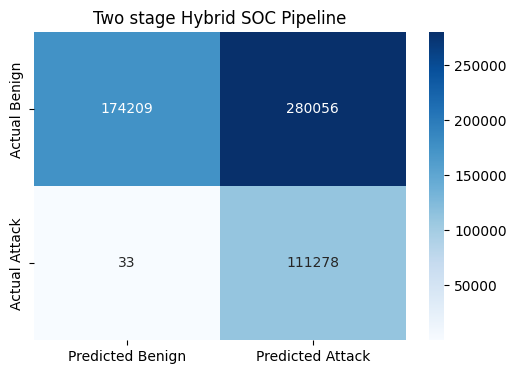

In [11]:
print('\n Final Hubrid Pipeline Evaluation')

# compare the final hybrid predictions against the actual true labels
print(classification_report(y_test, hybrid_predictions, target_names=['Benign (0)', 'Attack (1)'], digits=4))

total_attacks = np.sum(y_test == 1)
caught_by_xgb = np.sum((xgb_predictions == 1) & (y_test == 1))
caught_by_ae = np.sum((hybrid_predictions == 1) & (y_test == 1)) - caught_by_xgb
missed_attacks = total_attacks - (caught_by_xgb + caught_by_ae)

print(f'\n Total Actual Attacks: {total_attacks}')
print(f'Blocked by stage 1 (XGBoost): {caught_by_xgb}')
print(f'caught by stage 2 (Autoencoder zero-day filter): {caught_by_ae}')
print(f'Missed Completely: {missed_attacks}')

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, hybrid_predictions), annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Benign', 'Predicted Attack'],
            yticklabels=['Actual Benign', 'Actual Attack'])
plt.title('Two stage Hybrid SOC Pipeline')
plt.show()


Generating Reconstruction Error Distribution...


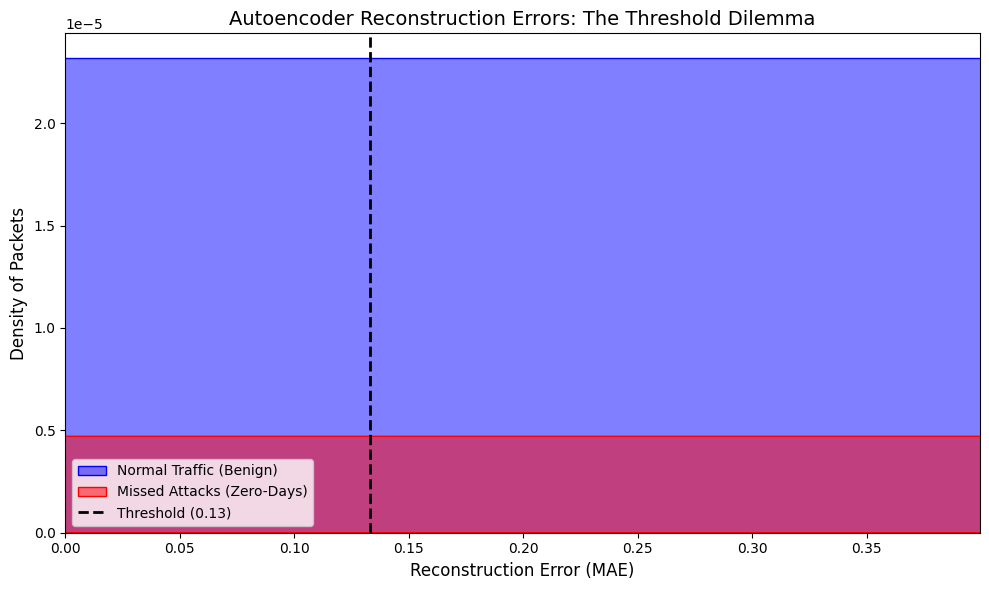

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Reconstruction Error Distribution...")

plt.figure(figsize=(10, 6))

# Plot the errors for Benign traffic (0)
sns.kdeplot(ae_errors[y_test.iloc[passed_by_xgboost_indices] == 0],
            color='blue', fill=True, label='Normal Traffic (Benign)', alpha=0.5, warn_singular=False)

# Plot the errors for the Zero-Day Attacks (1)
sns.kdeplot(ae_errors[y_test.iloc[passed_by_xgboost_indices] == 1],
            color='red', fill=True, label='Missed Attacks (Zero-Days)', alpha=0.5, warn_singular=False)

# Draw a line where your threshold was placed
plt.axvline(best_threshold, color='black', linestyle='dashed', linewidth=2, label=f'Threshold ({best_threshold:.2f})')

plt.title('Autoencoder Reconstruction Errors: The Threshold Dilemma', fontsize=14)
plt.xlabel('Reconstruction Error (MAE)', fontsize=12)
plt.ylabel('Density of Packets', fontsize=12)
# Limit the X-axis so we can actually see the overlap, ignoring massive outliers
plt.xlim(0, best_threshold * 3)
plt.legend()
plt.tight_layout()
plt.show()

Generating Precision-Recall Tradeoff Curve...


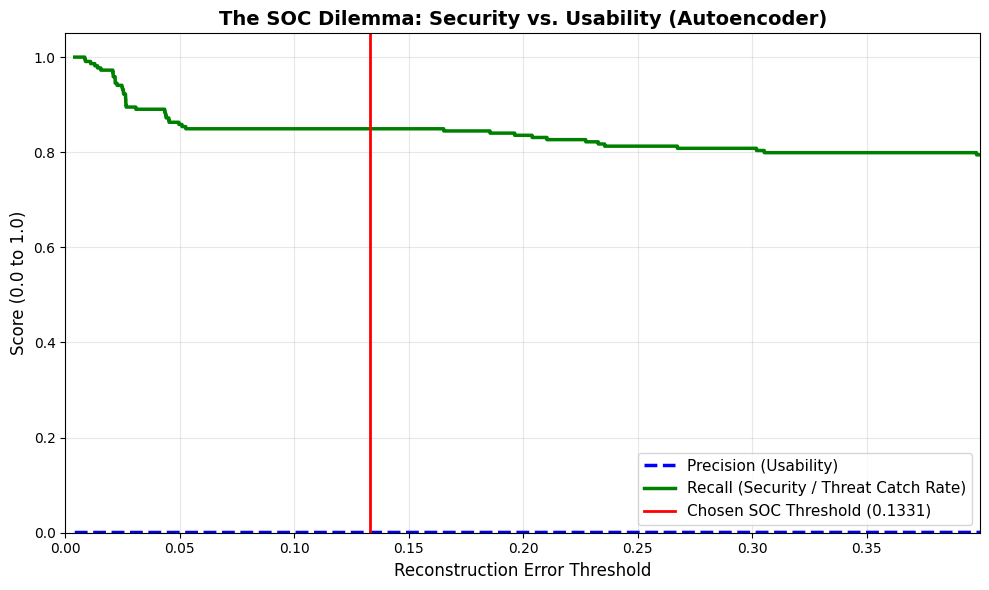

In [14]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

print("Generating Precision-Recall Tradeoff Curve...")

# Get the true labels for the traffic that reached the Autoencoder
y_test_ae = y_test.iloc[passed_by_xgboost_indices]

# Calculate the curves based on the errors in the pipeline
precisions, recalls, thresholds = precision_recall_curve(y_test_ae, ae_errors)

plt.figure(figsize=(10, 6))

# Plot Precision and Recall against the thresholds
# (We use [:-1] because thresholds has one less element than precisions/recalls)
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Usability)', linewidth=2.5)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Security / Threat Catch Rate)', linewidth=2.5)

# Draw a vertical line exactly where your best_threshold is
plt.axvline(x=best_threshold, color='red', linestyle='-', linewidth=2,
            label=f'Chosen SOC Threshold ({best_threshold:.4f})')

# Limit X-axis to focus on the action area
plt.xlim(0, best_threshold * 3)
plt.ylim(0, 1.05)

plt.title('The SOC Dilemma: Security vs. Usability (Autoencoder)', fontsize=14, fontweight='bold')
plt.xlabel('Reconstruction Error Threshold', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()